## Importing

### Meeting - Nicolas Courty (20/03)

- Different solvers for optimal transport can allow multiple solutions. The simplest OT solver has a bijection solution. However, sinkhorn allows the mass to be distributed unevenly and therefore not bijection anymore. The regularization parameter is essencial as give space to how tight the optimtransport plan should be. 

- In addition, prof. Nicolas reccomend do not transport the full image of size (2000x2000) into another bigger image, even tho we are talking about the embeddings of it. He points out that the domain shift for an object detection of dugong is local by nature. Therefore, he would reccomend to look at the patch embeddings and transport the distribution patch source from the target. 

- He points out that this image size is too much information being transported but also too much information presented on the embedding that could be poorly translated to the detection of dugong itself. 

- Optimal transport would have an limitation regarding dataset size, he pointed out that datasets >> 10,000. would be too big for OT problems. 

- To sum up, he recommend literature three different approach, first: flow matching; deppjdot; jumbot.

- Regarding how to execute an active learning and sample the best image set in order to select an optimal set of images to be labelled, he come out  with 2-sasmple Wasserstein Test. 

In [2]:
## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [8]:
import fiftyone.brain as fob
from sklearn.preprocessing import normalize
import plotly.express as px
import skdim
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ot
from sklearn.manifold import TSNE
import cv2
from fiftyone import ViewField as F

In [3]:
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.load_saved_view("New_Caledonia")
wp_view = dataset.load_saved_view("West_Papua")

In [6]:
## get embeddings for each view and normalize it 
## retrieve values
nc_emb = nc_view.values("full_embeddings")
wp_emb = wp_view.values("full_embeddings")

## convert to array
nc_emb = np.array(nc_emb)
wp_emb = np.array(wp_emb)

## normalize firsrt
nc_norm = normalize(nc_emb)
wp_norm = normalize(wp_emb)


# MLE

In [21]:
import time
from contextlib import contextmanager

@contextmanager
def timer(name):
    start = time.perf_counter()
    yield
    end = time.perf_counter()
    print(f"{name}: {end - start:.4f} s")
    
def calculate_MLE(dataset: np.ndarray, 
                  list_neighboors: list = [3,5,10,20],
                  verbose=True):
    """
    Computes Maximum Likelihood Estimation for a set of neighboors,
    Returns:
        list of MLE distances for each neighboor
    """
    def compute(dataset, 
                n_neighboors: int,
                n_jobs: int = 1):
        """
        Returns a float containing the intrinsic measure. 
        """
        mlea = skdim.id.MLE().fit_transform(X = dataset,
                                                n_neighbors = n_neighboors,
                                                n_jobs = 1)
        return mlea 
        
    results = {}
    for k in list_neighboors:
        if verbose:
            print(f"running {k}")
            with timer(f'k_{k}'):
                mlea = compute(dataset,
                               n_neighboors = k)
                results[k] = mlea
        else:
            mlea = compute(dataset,
                           n_neighboors = k)
            results[k] = mlea
    return results


In [9]:
GAM = wp_view.match(
    F("subregion")=="GAM"
)
FRIWEN = wp_view.match(
    F("subregion")=="FRIWEN"
)
MANTASANDY = wp_view.match(
    F("subregion")=="MANTASANDY"
)
UM = wp_view.match(
    F("subregion")=="UM"
)

In [18]:
gam_emb = GAM.values('full_embeddings')
friwen_emb = FRIWEN.values('full_embeddings')
um_emb = UM.values('full_embeddings')

norm_gam_emb = normalize(gam_emb)
norm_friwen_emb = normalize(friwen_emb)
norm_um_emb = normalize(um_emb)

In [29]:
print(f"WP- GAM: {len(GAM)}")
print(f"WP - FRIWEN: {len(FRIWEN)}")
print(f"WP - MANTASANDY: {len(MANTASANDY)}")
print(f"WP -UM: {len(UM)}")
print(f"NC: {len(nc_view)}")
print(f"WP (total): {len(wp_view)}")

WP- GAM: 512
WP - FRIWEN: 779
WP - MANTASANDY: 3
WP -UM: 745
NC: 716
WP (total): 2039


In [19]:
datasets_l ={'WP': wp_norm, 
             'NC' : nc_norm,
            'WP_GAM':norm_gam_emb,
            'WP_friwen':norm_friwen_emb,
            'WP_mant':norm_um_emb}


In [22]:
# Configuration
sample_sizes = [50, 100, 250, 500, 700]
neighbors_list = [3, 5, 10, 20]
n_iterations = 15

results_list = []

for name, data in datasets_l.items():
    print(f"Processing: {name}")
    for n in sample_sizes:
        if n > data.shape[0]: continue 
        
        for i in range(n_iterations):
            idx = np.random.choice(data.shape[0], size=n, replace=False)
            # Calculate MLE for all k at once for this specific sample
            res = calculate_MLE(dataset=data[idx],
                                 list_neighboors=neighbors_list,
                                 verbose=False)
            
            for k, val in res.items():
                results_list.append({
                    'Dataset': name,
                    'Sample Size': n,
                    'k': k,
                    'MLE': val
                })

df_interaction = pd.DataFrame(results_list)


Processing: WP
Processing: NC
Processing: WP_GAM
Processing: WP_friwen
Processing: WP_mant


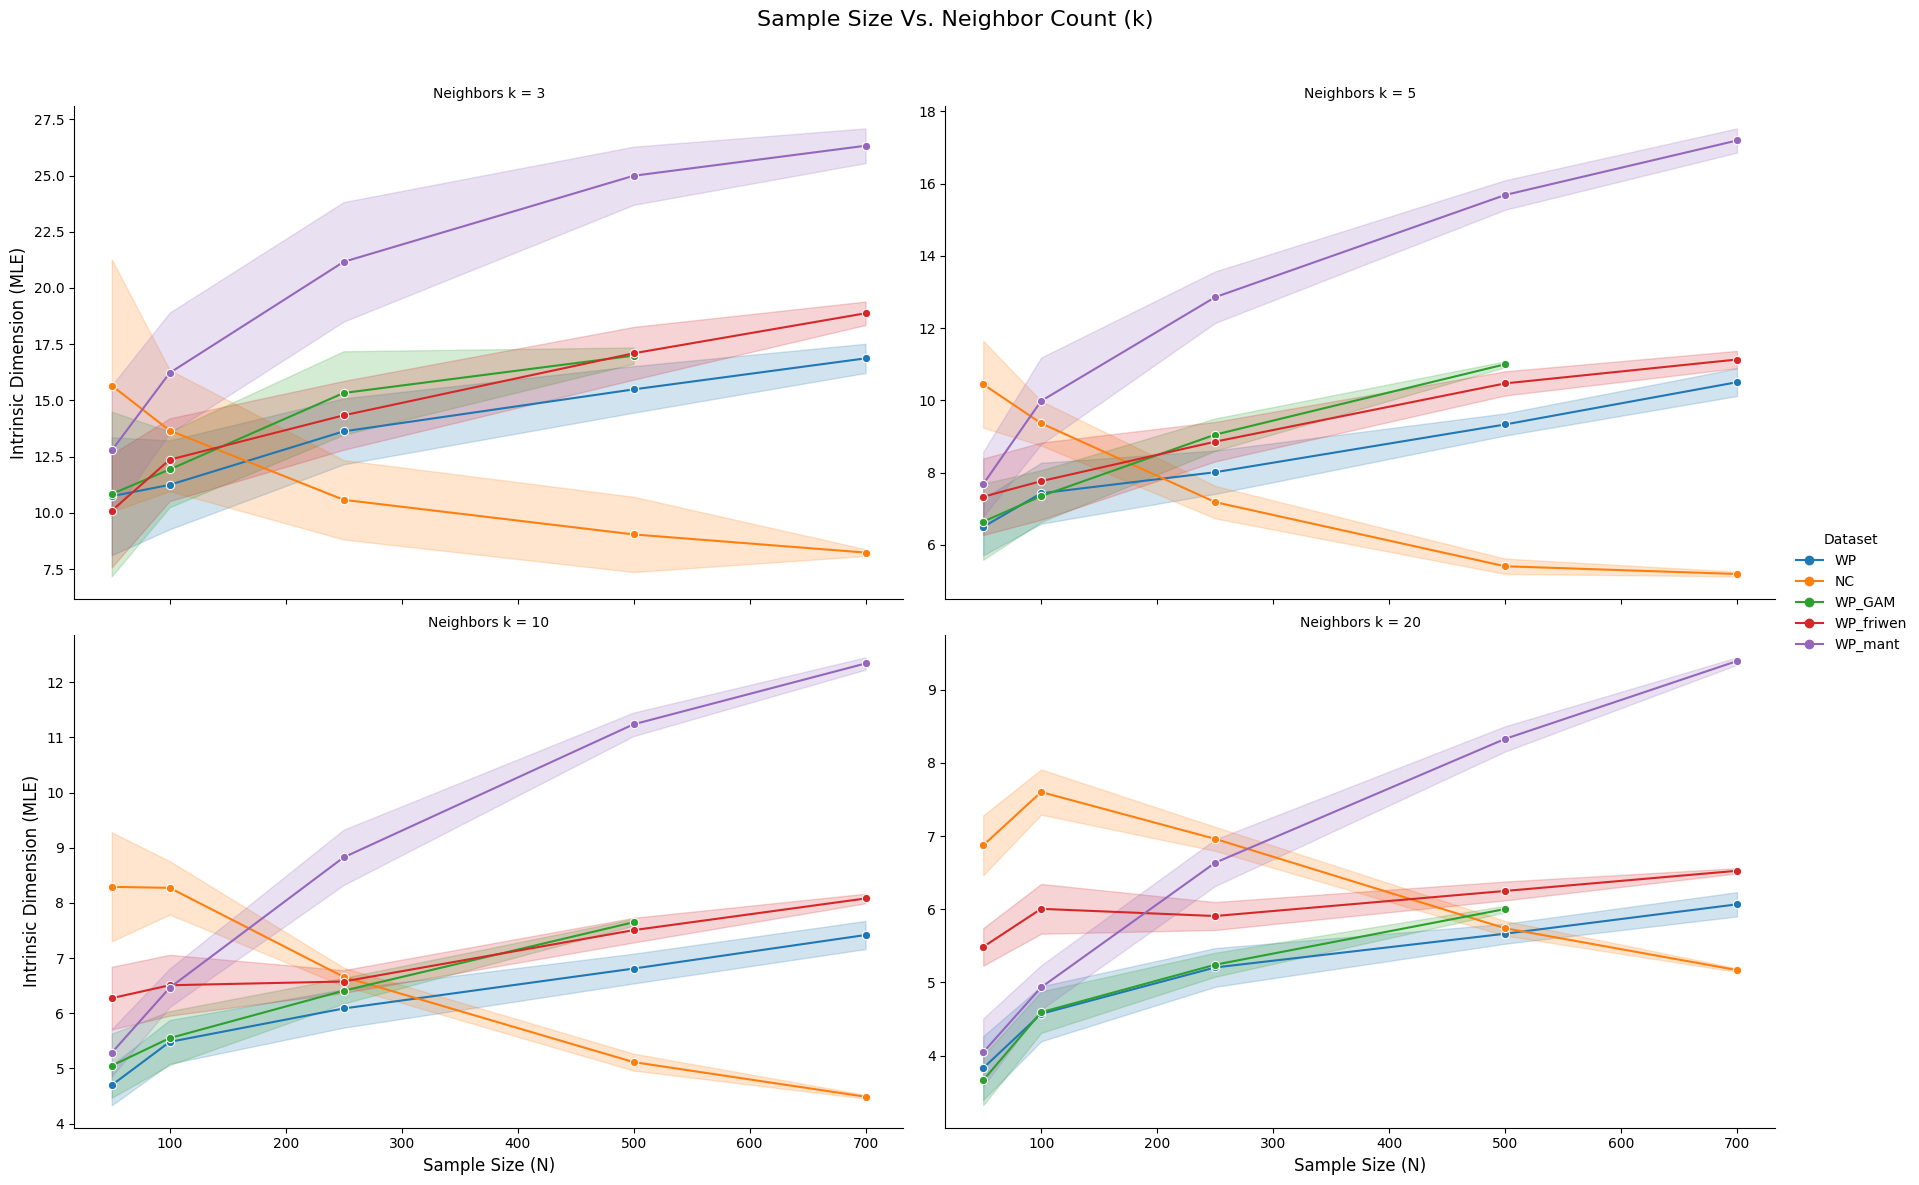

In [25]:
# plot
g = sns.relplot(
    data=df_interaction, 
    x='Sample Size', 
    y='MLE', 
    hue='Dataset', 
    col='k', 
    kind='line', 
    marker='o', 
    facet_kws={'sharey': False},
    errorbar='sd',
    col_wrap = 2,
    height = 6,
    aspect = 1.5
)

g.set_axis_labels("Sample Size (N)", "Intrinsic Dimension (MLE)",
                 fontsize=12)
g.set_titles("Neighbors k = {col_name}",fontsize=20)
plt.subplots_adjust(top=0.90)
g.fig.suptitle('Sample Size Vs. Neighbor Count (k)',fontsize=16)

plt.show()

## Optimal Transport 

Following Gerard assumption, we are applying optimal transport for the same number of samples. 

### Selecting the most representative images in WP

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_top_k_representatives(embeddings, n_clusters=10, top_k=20, random_state= 24):
    # scaling + PCA
    reduced_data = PCA(n_components=50).fit_transform(StandardScaler().fit_transform(embeddings))
    
    # fit K-Means
    kmeans = KMeans(n_clusters=n_clusters,
                    init='k-means++',
                    random_state=random_state
                   )
    cluster_labels = kmeans.fit_predict(reduced_data)
    centroids = kmeans.cluster_centers_
    
    representative_indices = {}

    for i in range(n_clusters):
        # Filter: Get indices of all points belonging to the current cluster
        in_cluster_idx = np.where(cluster_labels == i)[0]
        
        # Get the actual embeddings for these points
        cluster_embeddings = reduced_data[in_cluster_idx]
        
        # Calculate distance of each point in the cluster to its centroid
        # Reshape centroid to (1, -1) for pairwise_distances
        dist = pairwise_distances(cluster_embeddings, centroids[i].reshape(1, -1)).flatten()
        
        # Sort distances and get the original indices of the 'top_k' closest points
        # If the cluster has fewer than top_k points, it takes all of them
        k_closest_local_indices = np.argsort(dist)[:top_k]
        
        # Map local cluster indices back to original dataset indices
        representative_indices[f"Cluster_{i}"] = in_cluster_idx[k_closest_local_indices]
        
    return representative_indices

In [35]:

results = get_top_k_representatives(norm_gam_emb,
                                    n_clusters=3,
                                    top_k=20
                                   )
for cluster, indices in results.items():
    print(f"{cluster} has {len(indices)} representatives.")

Cluster_0 has 20 representatives.
Cluster_1 has 20 representatives.
Cluster_2 has 20 representatives.


In [36]:
results

{'Cluster_0': array([285, 310, 332, 497, 296, 493, 444, 313, 359, 320, 431, 483, 409,
        465, 426, 266, 424, 282, 280, 398]),
 'Cluster_1': array([495, 172, 429, 252,  68, 149, 443, 509, 374, 231, 117, 506, 386,
        507, 450,  52, 440, 142, 275, 333]),
 'Cluster_2': array([155, 148, 195,  40, 208, 217, 151,  73, 144,  84, 158,  32, 122,
        204,  41,  35,  87, 183, 140, 170])}

### Calculate OT

In [ ]:
with timer("Time taken to transport NC -> WP: "):
    ot_lpl1 = ot.da.SinkhornTransport(reg_e=0.05,
                                      max_iter = 1500,
                                      verbose=False,
                                      tol = 1e-8,
                                      )
    
    norm_nc = normalize(nc_emb)
    norm_wp = normalize(wp_emb)
    ot_lpl1.fit(Xs=norm_nc,
                Xt=norm_wp)

    nc_adapted = ot_lpl1.transform(Xs=norm_nc)  # shape (716, 1024)

    ## get the optimal transport plan
    ## coupling matrix
    coupling = ot_lpl1.coupling_
all_emb = np.vstack([nc_emb, nc_adapted, wp_emb])
all_emb_norm = normalize(all_emb)  # L2-normalize before t-SNE

## compute tsne on embeddings 
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, init='pca', learning_rate='auto')
emb_2d = tsne.fit_transform(all_emb_norm)

# Split back
n_nc = len(nc_emb)
n_wp = len(wp_emb)
nc_2d     = emb_2d[:n_nc]
nc_ad_2d  = emb_2d[n_nc:n_nc*2] ## adapated nc
wp_2d     = emb_2d[n_nc*2:]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Before adaptation ---
ax = axes[0]
ax.scatter(wp_2d[:, 0],    wp_2d[:, 1],    c='#2196F3', alpha=0.3, s=15, label='WP (target)')
ax.scatter(nc_2d[:, 0],    nc_2d[:, 1],    c='#F44336', alpha=0.6, s=20, label='NC (source)')
ax.set_title('Before Adaptation\n', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks([]); ax.set_yticks([])

# --- After adaptation ---
ax = axes[1]
ax.scatter(wp_2d[:, 0],    wp_2d[:, 1],    c='#2196F3', alpha=0.3, s=15, label='WP (target)')
ax.scatter(nc_ad_2d[:, 0], nc_ad_2d[:, 1], c='#FF9800', alpha=0.6, s=15, label='NC adapted')
ax.scatter(nc_2d[:, 0],    nc_2d[:, 1],    c='#F44336', alpha=0.1, s=10, label='NC original')
ax.set_title('After Adaptation\nNC embeddings transported → WP space', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()
